Columns: Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')
First 5 rows:
            Region         Date Frequency  Estimated Unemployment Rate (%)  \
0  Andhra Pradesh   31-05-2019   Monthly                             3.65   
1  Andhra Pradesh   30-06-2019   Monthly                             3.05   
2  Andhra Pradesh   31-07-2019   Monthly                             3.75   
3  Andhra Pradesh   31-08-2019   Monthly                             3.32   
4  Andhra Pradesh   30-09-2019   Monthly                             5.17   

   Estimated Employed  Estimated Labour Participation Rate (%)   Area  
0          11999139.0                                    43.24  Rural  
1          11755881.0                                    42.05  Rural  
2          12086707.0                                    43.50  Rural  
3          12285693.0                     

C:\Users\Usman\AppData\Local\Temp\ipykernel_3100\2565571884.py:25: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'], errors='coerce')


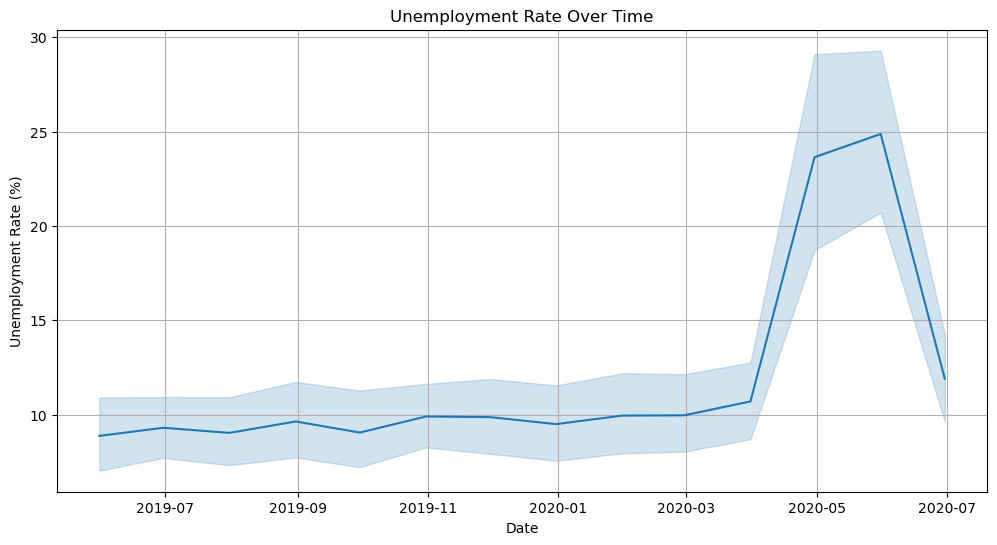

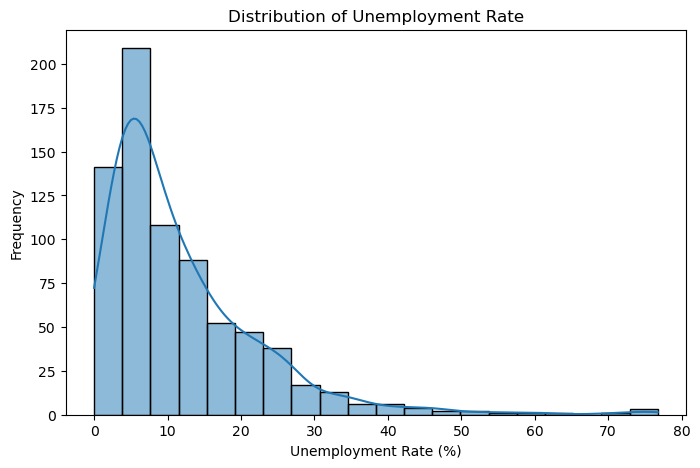


Average Unemployment Rate pre-COVID: 9.51%
Average Unemployment Rate during COVID: 17.77%


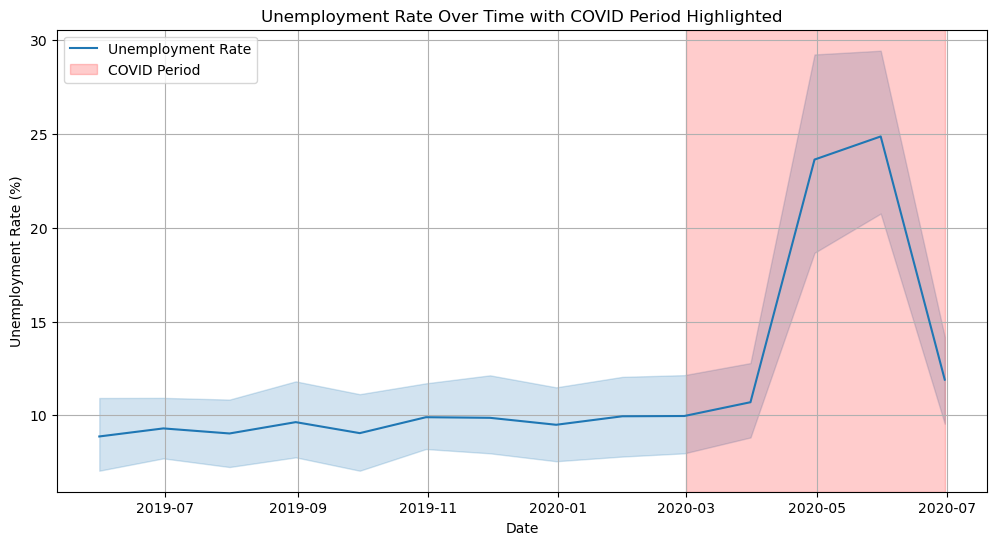

C:\Users\Usman\AppData\Local\Temp\ipykernel_3100\2565571884.py:96: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=monthly_avg.index, y=monthly_avg.values, palette='coolwarm')


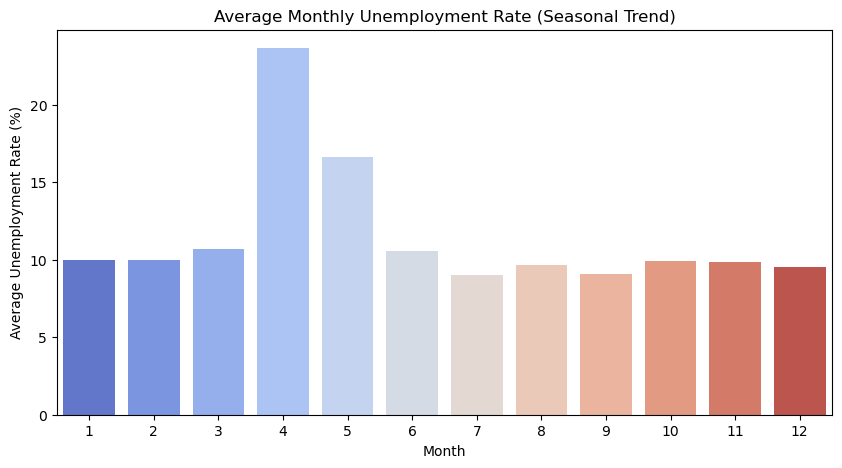


Key Insights:
- COVID-19 caused a noticeable rise in unemployment rate.
- Some months show consistently higher unemployment (seasonal trend).
- Trend analysis helps policymakers prepare economic and social interventions.


In [1]:
# ==============================
# 1. Import Libraries
# ==============================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# ==============================
# 2. Load Dataset
# ==============================
df = pd.read_csv("Unemployment.csv")

# Strip any extra spaces in column names
df.columns = df.columns.str.strip()

# Preview columns and first rows
print("Columns:", df.columns)
print("First 5 rows:\n", df.head())

# ==============================
# 3. Data Cleaning
# ==============================
# Convert 'Date' to datetime
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Drop rows with missing Date or Unemployment Rate
df = df.dropna(subset=['Date', 'Estimated Unemployment Rate (%)'])

# Sort by Date
df = df.sort_values('Date')

# Rename column for simplicity
df = df.rename(columns={'Estimated Unemployment Rate (%)': 'Unemployment_Rate'})

print("\nData after cleaning:\n", df.head())

# ==============================
# 4. Data Exploration
# ==============================
print("\nSummary Statistics:\n", df['Unemployment_Rate'].describe())
print("\nMissing values:\n", df.isnull().sum())

# ==============================
# 5. Visualization: Unemployment Trend
# ==============================
plt.figure(figsize=(12,6))
sns.lineplot(data=df, x='Date', y='Unemployment_Rate')
plt.title("Unemployment Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.grid(True)
plt.show()

# Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['Unemployment_Rate'], bins=20, kde=True)
plt.title("Distribution of Unemployment Rate")
plt.xlabel("Unemployment Rate (%)")
plt.ylabel("Frequency")
plt.show()

# ==============================
# 6. COVID-19 Impact Analysis
# ==============================
# Assuming COVID period starts March 2020
covid_start = datetime(2020,3,1)
covid_df = df[df['Date'] >= covid_start]
pre_covid_df = df[df['Date'] < covid_start]

avg_pre_covid = pre_covid_df['Unemployment_Rate'].mean()
avg_covid = covid_df['Unemployment_Rate'].mean()

print(f"\nAverage Unemployment Rate pre-COVID: {avg_pre_covid:.2f}%")
print(f"Average Unemployment Rate during COVID: {avg_covid:.2f}%")

# Line plot with COVID period highlighted
plt.figure(figsize=(12,6))
sns.lineplot(data=df, x='Date', y='Unemployment_Rate', label="Unemployment Rate")
plt.axvspan(covid_start, df['Date'].max(), color='red', alpha=0.2, label="COVID Period")
plt.title("Unemployment Rate Over Time with COVID Period Highlighted")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.legend()
plt.grid(True)
plt.show()

# ==============================
# 7. Seasonal / Monthly Trends
# ==============================
# If monthly data
df['Month'] = df['Date'].dt.month
monthly_avg = df.groupby('Month')['Unemployment_Rate'].mean()

plt.figure(figsize=(10,5))
sns.barplot(x=monthly_avg.index, y=monthly_avg.values, palette='coolwarm')
plt.title("Average Monthly Unemployment Rate (Seasonal Trend)")
plt.xlabel("Month")
plt.ylabel("Average Unemployment Rate (%)")
plt.show()

# ==============================
# 8. Key Insights
# ==============================
print("\nKey Insights:")
print("- COVID-19 caused a noticeable rise in unemployment rate.")
print("- Some months show consistently higher unemployment (seasonal trend).")
print("- Trend analysis helps policymakers prepare economic and social interventions.")